Shape: (380, 4)

Columns:
['Gender', 'Age', 'EstimatedSalary', 'Purchased']

First 5 rows:
   Gender  Age  EstimatedSalary  Purchased
0       1   19            19000          0
1       1   35            20000          0
2       0   26            43000          0
3       0   27            57000          0
4       1   19            76000          0

===== Decision Tree =====
Confusion Matrix:
[[40  8]
 [ 6 22]]
Accuracy : 0.8157894736842105
Precision: 0.8193745232646834
Recall   : 0.8157894736842105
F1-Score : 0.8170058307912114


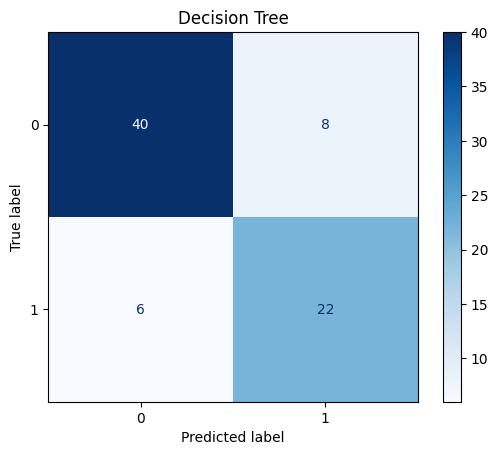


===== KNN =====
Confusion Matrix:
[[43  5]
 [ 2 26]]
Accuracy : 0.9078947368421053
Precision: 0.9125070741369552
Recall   : 0.9078947368421053
F1-Score : 0.9087508273143218


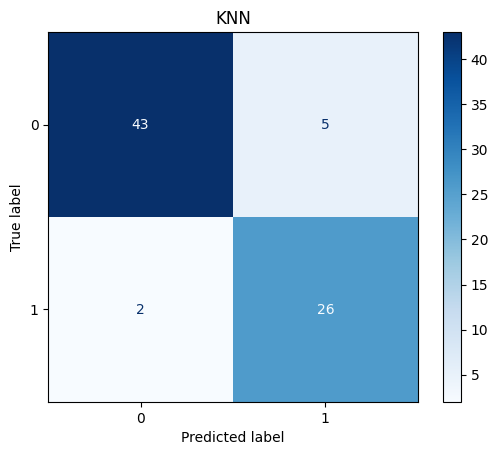


===== Naive Bayes =====
Confusion Matrix:
[[43  5]
 [ 4 24]]
Accuracy : 0.881578947368421
Precision: 0.8827277290805885
Recall   : 0.881578947368421
F1-Score : 0.881994459833795


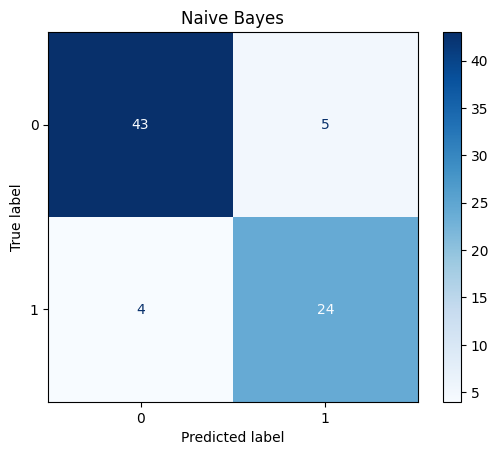


Final Comparison:
           Model  Accuracy  Precision    Recall  F1-Score
0            KNN  0.907895   0.912507  0.907895  0.908751
1    Naive Bayes  0.881579   0.882728  0.881579  0.881994
2  Decision Tree  0.815789   0.819375  0.815789  0.817006

Best Model: KNN
Best Accuracy: 0.9078947368421053


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


file_path = "../data/purchase_prediction_classification.csv"
target_col = "Purchased"

df = pd.read_csv(file_path)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ===================================================================================
def evaluate_model(model_name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)

    acc = accuracy_score(y_true, y_pred)
    pre = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print(f"\n===== {model_name} =====")
    print("Confusion Matrix:")
    print(cm)
    print("Accuracy :", acc)
    print("Precision:", pre)
    print("Recall   :", rec)
    print("F1-Score :", f1)

    ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
    plt.title(model_name)
    plt.show()

    return acc, pre, rec, f1
# ===================================================================================


# decision tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc, dt_pre, dt_rec, dt_f1 = evaluate_model("Decision Tree", y_test, dt_pred)

# KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)
knn_acc, knn_pre, knn_rec, knn_f1 = evaluate_model("KNN", y_test, knn_pred)


# naive bayes
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
nb_pred = nb.predict(X_test_scaled)
nb_acc, nb_pre, nb_rec, nb_f1 = evaluate_model("Naive Bayes", y_test, nb_pred)


# results models
results = pd.DataFrame({
    "Model": ["Decision Tree", "KNN", "Naive Bayes"],
    "Accuracy": [dt_acc, knn_acc, nb_acc],
    "Precision": [dt_pre, knn_pre, nb_pre],
    "Recall": [dt_rec, knn_rec, nb_rec],
    "F1-Score": [dt_f1, knn_f1, nb_f1]
})

best_model = results.iloc[results["Accuracy"].idxmax()]
print("\nBest Model:", best_model["Model"])
print("Best Accuracy:", best_model["Accuracy"])